# Breast Cancer Subtype Prediction
# Step 6: Final Feature Selection (mRMR) & Classification
# Goal: Combine RNA & Methylation, Select Best 50 Features, Train Final Models.

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from imblearn.over_sampling import SMOTE

print("✅ Libraries Imported.")

✅ Libraries Imported.


## Define IO & mRMR Functions


In [11]:
io_dir = '../outputs'

def load_object(filename):
    file_path = os.path.join(io_dir, filename + '.pkl')
    with open(file_path, 'rb') as f:
        return pickle.load(f)

def save_object(obj, filename):
    file_path = os.path.join(io_dir, filename + '.pkl')
    with open(file_path, 'wb') as f:
        pickle.dump(obj, f, pickle.HIGHEST_PROTOCOL)
    print(f"💾 Saved: {file_path}")

def mrmr_selection(X, y, k=50):
    n_features = X.shape[1]
    selected = []
    candidates = list(range(n_features))
    
    
    relevance = mutual_info_classif(X, y, random_state=42)
    
    
    first_feature = np.argmax(relevance)
    selected.append(first_feature)
    candidates.remove(first_feature)
    
    print(f"Selecting {k} features using mRMR...")
    

    for i in range(k - 1):
        mrmr_scores = []
        
        for feature in candidates:
            
            rel = relevance[feature]
            
            
            red = 0
            for sel_feat in selected:
                red += np.abs(np.corrcoef(X[:, feature], X[:, sel_feat])[0, 1])
            red /= len(selected)
            
            
            mrmr_scores.append(rel - red)
        
        
        best_candidate_idx = np.argmax(mrmr_scores)
        best_feature = candidates[best_candidate_idx]
        
        selected.append(best_feature)
        candidates.remove(best_feature)
        
        if (i+1) % 10 == 0:
            print(f"Selected {len(selected)}/{k} features...")
            
    return np.array(selected)

print("✅ Functions Ready.")

✅ Functions Ready.


## Load Data (From Step 3 - ReliefF)

In [ ]:
print("Loading ReliefF selected data...")

try:
    X_train_rna = load_object('X_train_rna_relief')
    X_test_rna = load_object('X_test_rna_relief')
    feat_indices_rna = load_object('feat_indices_rna_relief')
    
    X_train_meth = load_object('X_train_meth_relief')
    X_test_meth = load_object('X_test_meth_relief')
    feat_indices_meth = load_object('feat_indices_meth_relief')
    
    
    y_train = load_object('y_train')
    y_test = load_object('y_test')
    
    print("\nData Loaded.")
    print(f"RNA Features: {X_train_rna.shape[1]}")
    print(f"Meth Features: {X_train_meth.shape[1]}")
    
except FileNotFoundError:
    print("❌ Error: Files not found. Run Step 3 (ReliefF) first.")

Loading ReliefF selected data...

Data Loaded.
RNA Features: 48
Meth Features: 150


## Combine Datasets (Integration)


In [ ]:
X_train_combined = np.hstack((X_train_rna, X_train_meth))
X_test_combined = np.hstack((X_test_rna, X_test_meth))

combined_indices = []
combined_indices.extend([f"RNA_{i}" for i in feat_indices_rna])
combined_indices.extend([f"Meth_{i}" for i in feat_indices_meth])

print(f"Combined Train Shape: {X_train_combined.shape}")
print(f"Combined Test Shape:  {X_test_combined.shape}")

Combined Train Shape: (439, 198)
Combined Test Shape:  (110, 198)


## Apply mRMR Selection


In [ ]:
K_FINAL = 50

final_indices_local = mrmr_selection(X_train_combined, y_train, k=K_FINAL)

X_train_final = X_train_combined[:, final_indices_local]
X_test_final = X_test_combined[:, final_indices_local]

final_feature_names = [combined_indices[i] for i in final_indices_local]

print(f"✅ Final Selection Done. Shape: {X_train_final.shape}")
print("Top 5 Selected Features:", final_feature_names[:5])

Selecting 50 features using mRMR...
Selected 11/50 features...
Selected 21/50 features...
Selected 31/50 features...
Selected 41/50 features...
✅ Final Selection Done. Shape: (439, 50)
Top 5 Selected Features: ['Meth_5587', 'RNA_7442', 'RNA_9903', 'Meth_11208', 'RNA_16275']


## Data Balancing (SMOTE)


In [6]:
print("Balancing classes using SMOTE...")
print(f"Original Train Counts: {np.bincount(y_train)}")

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_final, y_train)

print(f"Balanced Train Counts: {np.bincount(y_train_balanced)}")

Balancing classes using SMOTE...
Original Train Counts: [237  97  28  77]
Balanced Train Counts: [237 237 237 237]


## Final Classification & Validation


Training KNN...
--- KNN Results ---
              precision    recall  f1-score   support

        LumA       0.91      0.53      0.67        59
        LumB       0.44      0.76      0.56        25
        Her2       0.46      0.86      0.60         7
       Basal       0.95      1.00      0.97        19

    accuracy                           0.68       110
   macro avg       0.69      0.79      0.70       110
weighted avg       0.78      0.68      0.69       110

Training SVM...
--- SVM Results ---
              precision    recall  f1-score   support

        LumA       0.87      0.81      0.84        59
        LumB       0.67      0.72      0.69        25
        Her2       0.75      0.86      0.80         7
       Basal       0.95      1.00      0.97        19

    accuracy                           0.83       110
   macro avg       0.81      0.85      0.83       110
weighted avg       0.83      0.83      0.83       110

Training Random Forest...
--- Random Forest Results ---
  

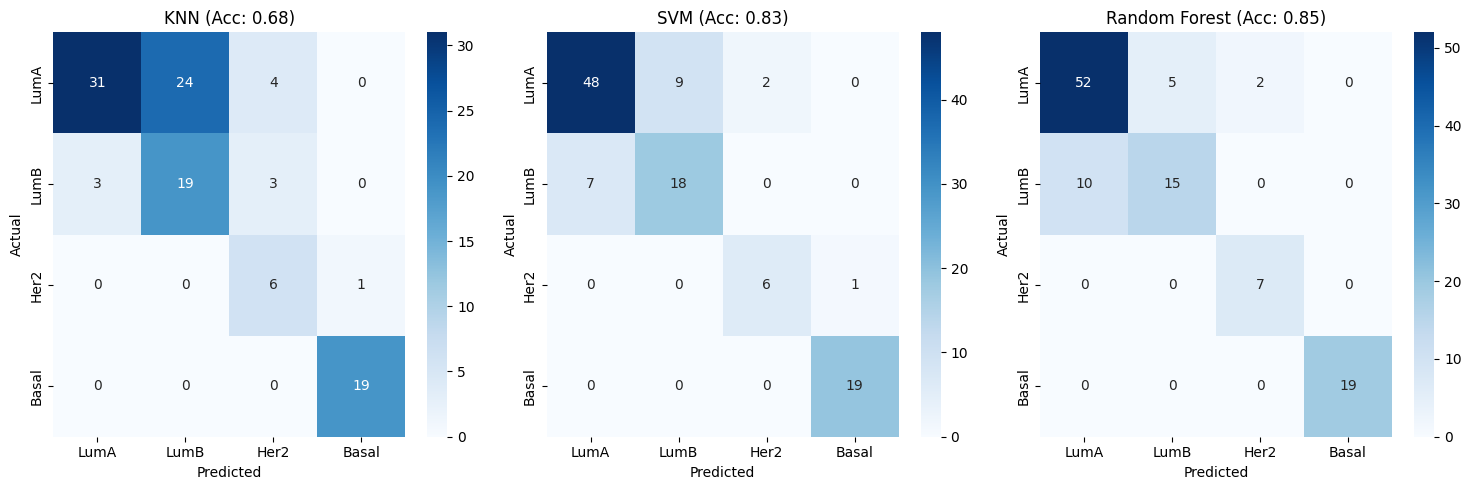

In [ ]:
models = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='rbf', C=1.0, probability=True),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
class_names = ['LumA', 'LumB', 'Her2', 'Basal']

plt.figure(figsize=(15, 5))

for i, (name, model) in enumerate(models.items()):
    print(f"Training {name}...")
    
    model.fit(X_train_balanced, y_train_balanced)
    
    y_pred = model.predict(X_test_final)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"--- {name} Results ---")
    print(classification_report(y_test, y_pred, target_names=class_names))
    
    plt.subplot(1, 3, i+1)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{name} (Acc: {acc:.2f})")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

plt.tight_layout()
plt.show()

## Saving Final Results


In [ ]:
print("Saving Final Project Outputs to '../outputs/'...")

best_model_name = max(results, key=results.get)
print(f"🏆 Best Model: {best_model_name} with Accuracy: {results[best_model_name]:.4f}")

save_object(X_train_final, 'Final_X_train')
save_object(X_test_final, 'Final_X_test')
save_object(y_train, 'Final_y_train')
save_object(y_test, 'Final_y_test')

save_object(final_feature_names, 'Final_Feature_Names')

print("\n🎉 PROJECT COMPLETED SUCCESSFULLY!")

Saving Final Project Outputs to '../outputs/'...
🏆 Best Model: Random Forest with Accuracy: 0.8455
💾 Saved: ../outputs\Final_X_train.pkl
💾 Saved: ../outputs\Final_X_test.pkl
💾 Saved: ../outputs\Final_y_train.pkl
💾 Saved: ../outputs\Final_y_test.pkl
💾 Saved: ../outputs\Final_Feature_Names.pkl

🎉 PROJECT COMPLETED SUCCESSFULLY!
